In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


In [4]:
df.shape

(3803, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3803 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   f

In [9]:
df.duplicated().sum()

np.int64(126)

In [13]:
df.drop_duplicates(inplace=True)

Property_type

<Axes: xlabel='property_type'>

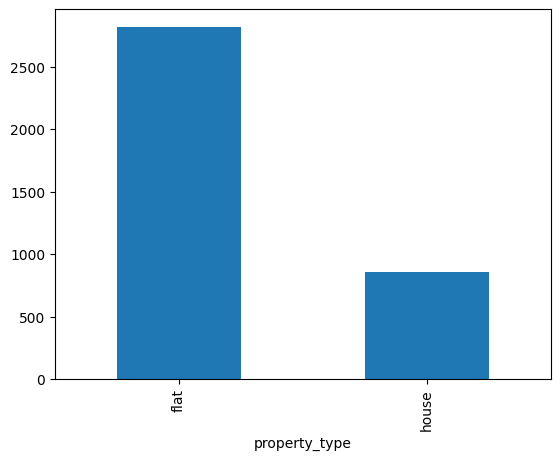

In [14]:
df['property_type'].value_counts().plot(kind='bar')

Society 

In [15]:
df['society'].value_counts().shape

(676,)

In [16]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
                                       ... 
rail vihar cghs                           1
rk tower                                  1
antriksh green                            1
imperia elvedor                           1
m3m golf hills                            1
Name: count, Length: 676, dtype: int64

In [18]:
# so many type this is not going to work ,we have to do  something with this

In [22]:
df[df['society']!='independent']['society'].value_counts(normalize=True).cumsum().head(75)


society
tulip violet                            0.023511
ss the leaf                             0.046395
shapoorji pallonji joyville gurugram    0.059561
dlf new town heights                    0.072727
signature global park                   0.083699
                                          ...   
ramsons kshitij                         0.490282
ats kocoon                              0.494357
ansal heights 86                        0.498433
ireo the corridors                      0.502194
mvn athens                              0.505956
Name: proportion, Length: 75, dtype: float64

In [23]:
# so 75 society have 50 % property if we not consider society-independent 

In [24]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(60),
 'Low (2-9)': np.int64(16),
 'Very Low (1)': np.int64(0)}

In [25]:
# There are a total of 104 unique sectors in the dataset.
# major sector have propety in between 10 to 49

Price

In [26]:
df['price'].isnull().sum()

np.int64(17)

In [36]:
df['price'].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

In [ ]:
# median of our property is 1.52 cr

<Axes: xlabel='price', ylabel='Count'>

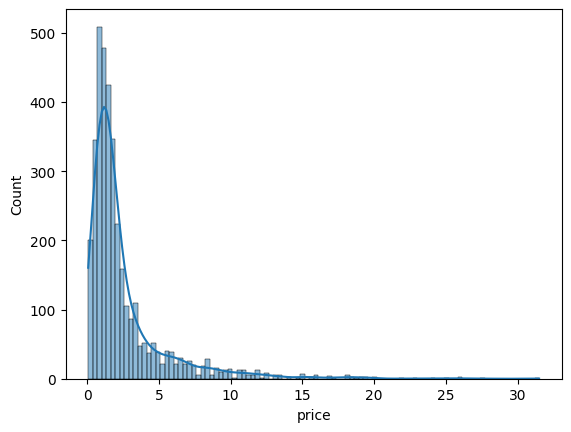

In [29]:
 sns.histplot(df['price'],kde=True,bins=100)

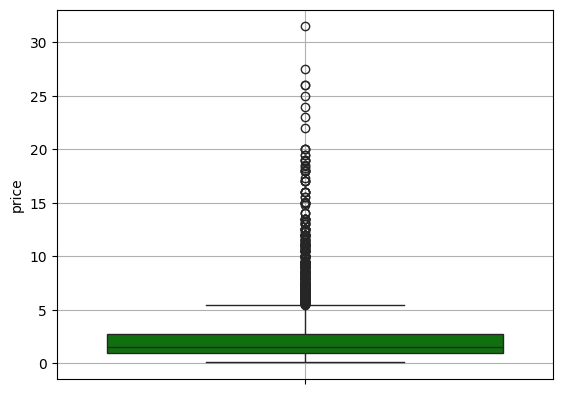

In [35]:
sns.boxplot(df['price'],color='green')
plt.grid()

In [33]:
# most proopet is between 0 to 10 cr , few beyond 10 cr
# so many outlier i have to do  something, its right skew data i  can apply log function

In [37]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.2791704733134623 14.933372629214258


In [38]:
# 3.28 indicate right skew property 
# kurtosis value greater than 3 indicate distribution with heavier tails

In [39]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64

In [40]:
#so 95 % property price is below 8.5 cr

In [44]:
Q1=df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1
IQR

np.float64(1.8)

In [45]:

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [46]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [47]:
# based on IQR methode , 425 property price consider as outklier

<Axes: xlabel='price'>

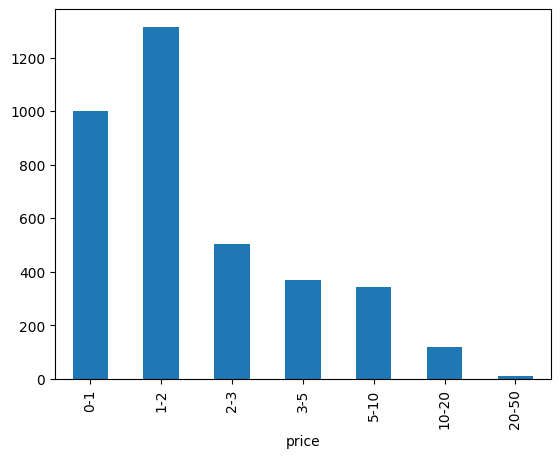

In [50]:
bins=[0,1,2,3,5,10,20,50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'],bins=bins,labels=bin_labels,right=False).value_counts().sort_index().plot(kind='bar')

In [51]:
# major data is in between 0 to 2 crs

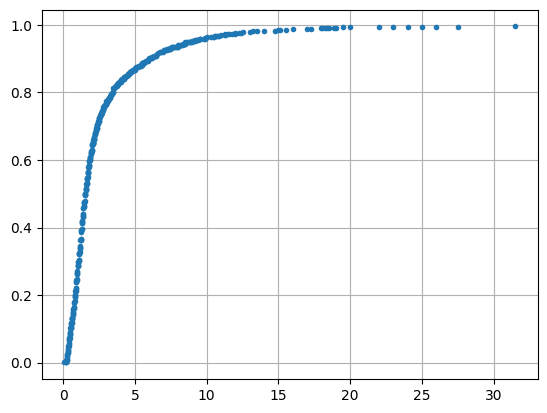

In [52]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()


In [53]:
# ecdf(Empirical Cumulative Distribution Function)- What fraction of properties have a price less than or equal to a given price
#almost 90% of property in equaal  to or less than 5 cr

Text(0, 0.5, 'Frequency')

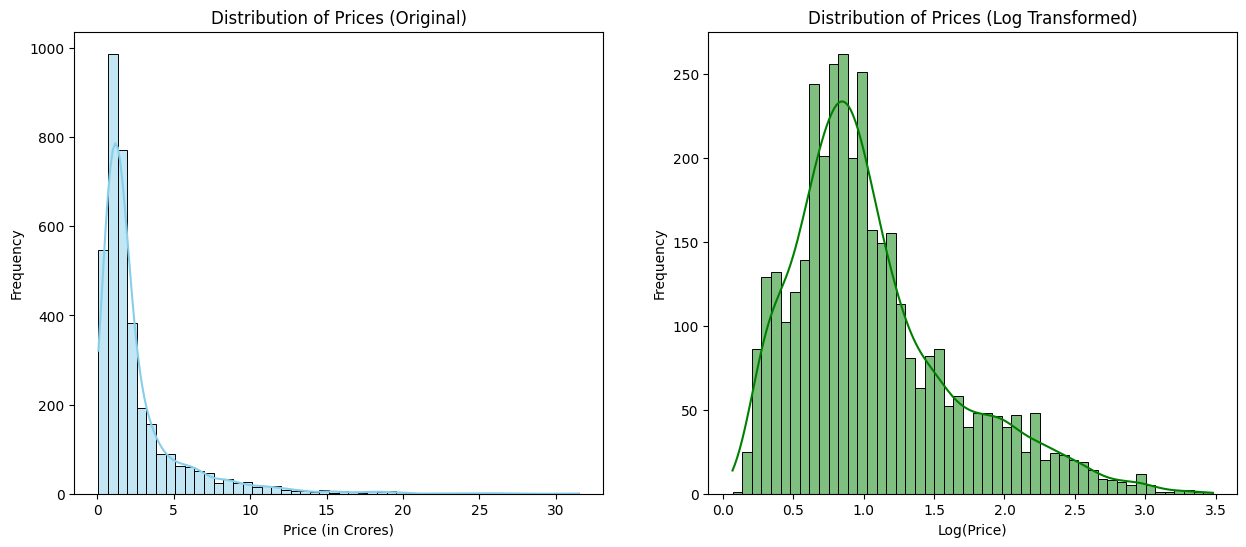

In [62]:
plt.figure(figsize=(15, 6))

# without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

#  plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='green')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')



In [58]:
# so by using log1p we van improve our distribution

In [59]:

skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255315 0.9646692415449296


In [61]:
#big improvement

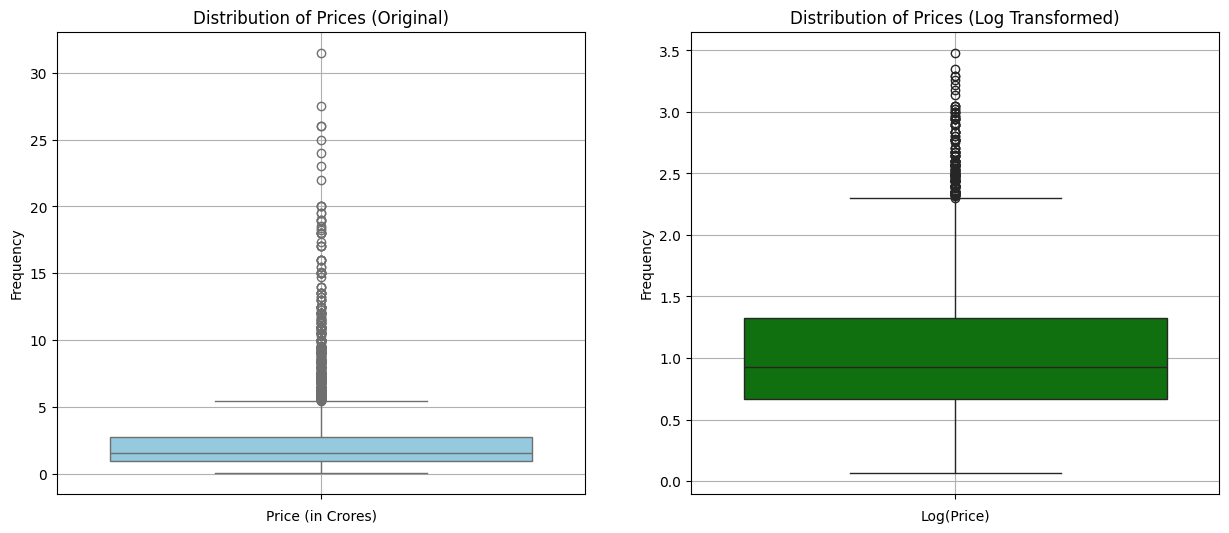

In [66]:
plt.figure(figsize=(15, 6))

# without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'],color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')
plt.grid()

#  plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']),color='green')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.grid()

Price_per_sqft


In [67]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [68]:
df['price_per_sqft'].describe()

count      3660.000000
mean      13892.668306
std       23210.067190
min           4.000000
25%        6817.250000
50%        9020.000000
75%       13880.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

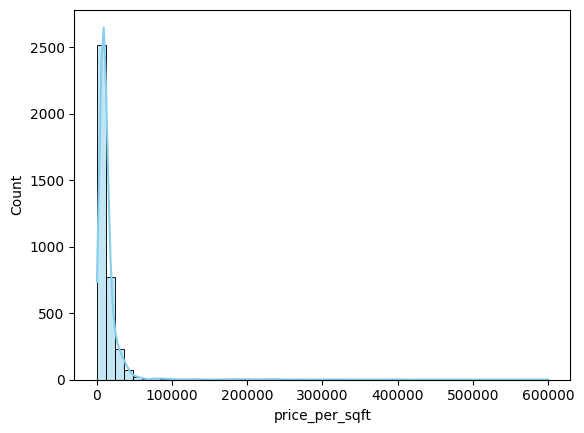

In [69]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='price_per_sqft'>

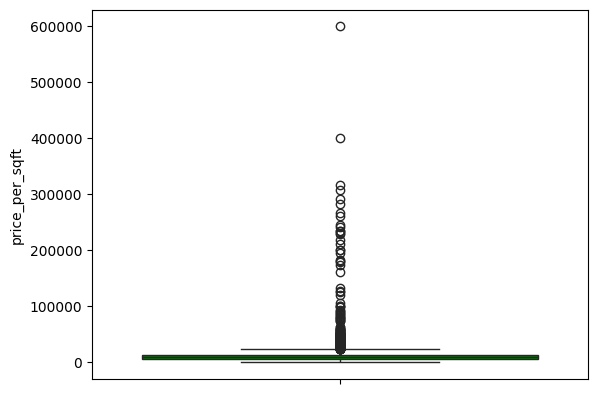

In [70]:

sns.boxplot(df['price_per_sqft'], color='green')

In [72]:
# almost same behaviour as price

BedRoom

In [74]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

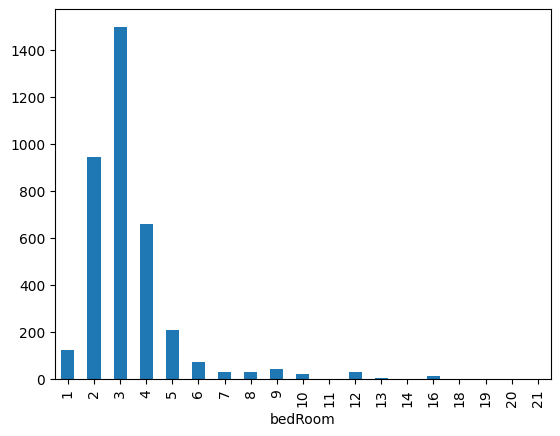

In [75]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

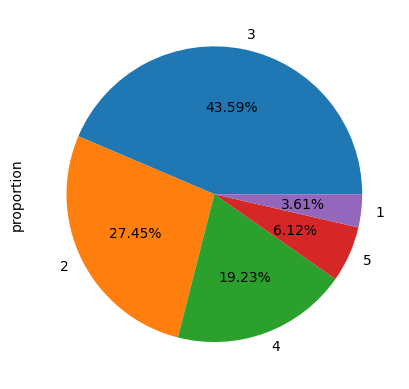

In [86]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [78]:
# about 40 % property are 3 bhk

bathroom

In [79]:

df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

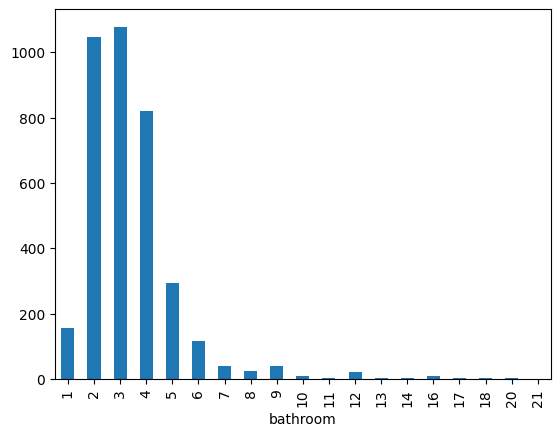

In [80]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

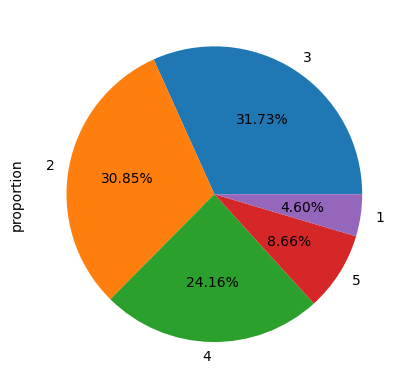

In [81]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [82]:

df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


Balcony

In [83]:

df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

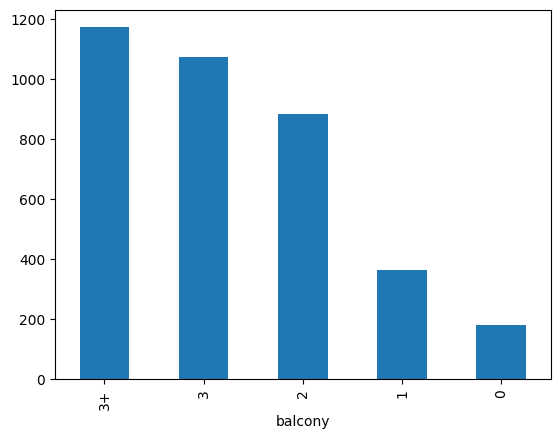

In [84]:

df['balcony'].value_counts().plot(kind='bar')


<Axes: ylabel='proportion'>

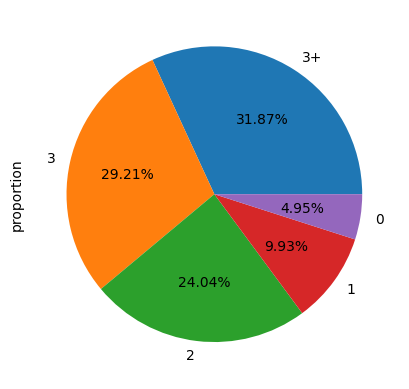

In [87]:

df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

floorNum

In [88]:
df.iloc[:,10:].head()


,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


In [89]:

df['floorNum'].isnull().sum()

np.int64(19)

In [90]:


df['floorNum'].describe()

count    3658.000000
mean        6.798250
std         6.012454
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

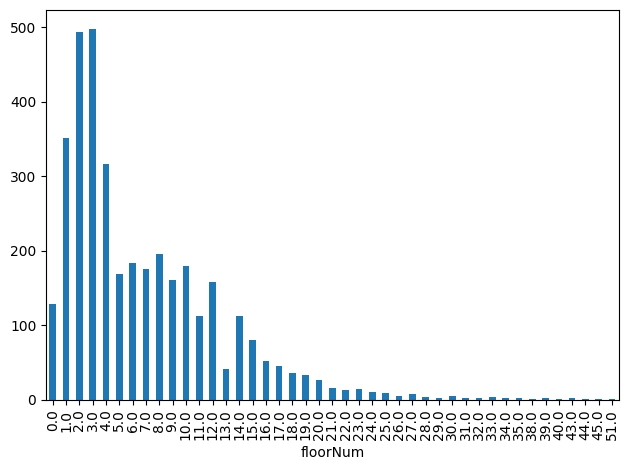

In [92]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')
plt.tight_layout()


<Axes: ylabel='floorNum'>

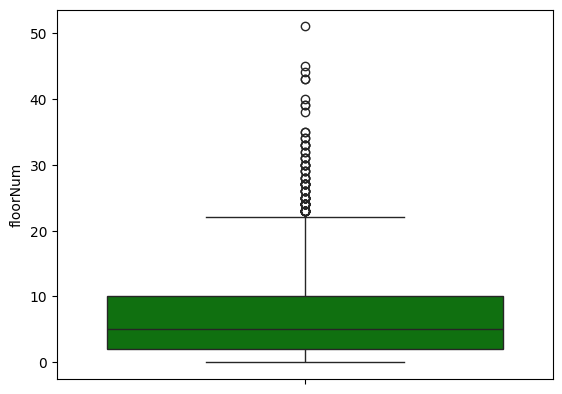

In [93]:
sns.boxplot(df['floorNum'], color='green')

In [94]:
# major property are in flooor 0  to 25
# floors i to 4  are particularly common

facing

In [95]:

df['facing'].isnull().sum()

np.int64(1045)

In [96]:
df['facing'].fillna('NA',inplace=True)

C:\Users\CHETAN CHOUDHARY\AppData\Local\Temp\ipykernel_13684\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [97]:

df['facing'].value_counts()

facing
NA            1045
North-East     623
East           623
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

agePossession

In [98]:

df['agePossession'].isnull().sum()


np.int64(0)

In [99]:

df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         563
Undefined              306
Old Property           303
Under Construction     266
Name: count, dtype: int64


areas

In [100]:
df['super_built_up_area'].isnull().sum()

np.int64(1802)

In [101]:

df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

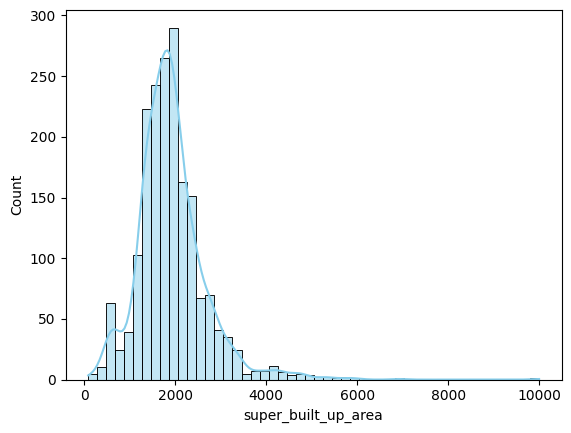

In [102]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

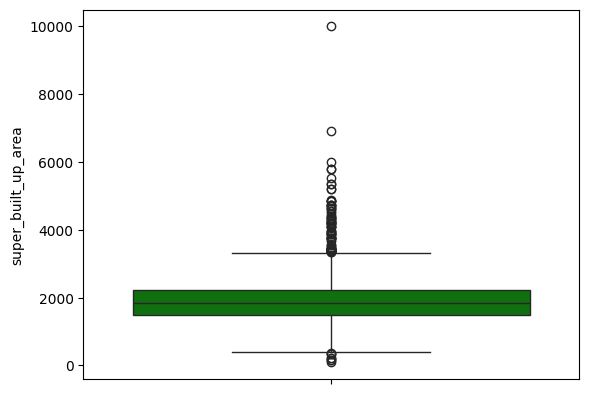

In [104]:
sns.boxplot(df['super_built_up_area'].dropna(), color='green')

In [105]:
# most property has bulid up area betweeen 1,000 sq.ft and 2,500 sq.ft.

# about  50% area lay on25%       1479.500000  - 75%       2215.000000
 # there are also property with unsual large areea - outlier


In [106]:
# built up area
df['built_up_area'].isnull().sum()


np.int64(1987)

In [107]:

df['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

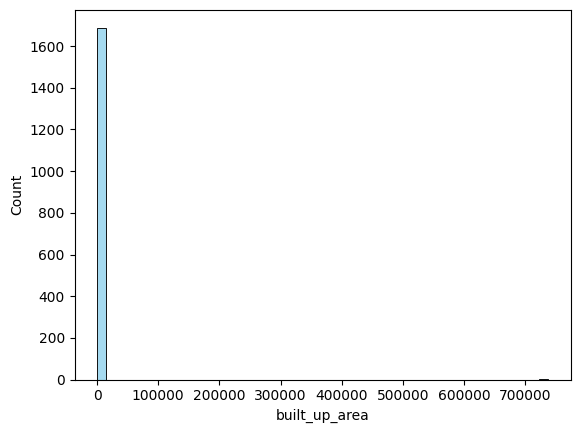

In [109]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

In [110]:
# one property with  700k is making problem may be cause by feature engineering step

<Axes: ylabel='built_up_area'>

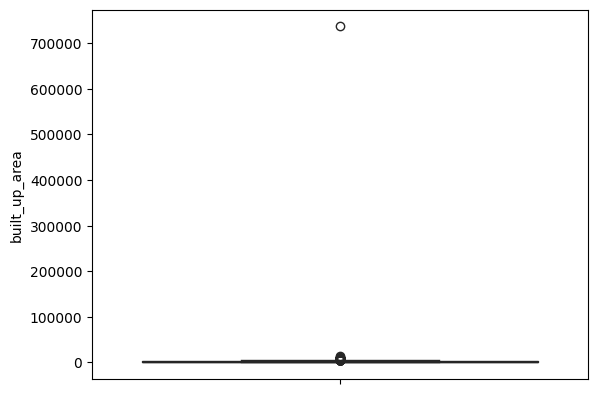

In [111]:
sns.boxplot(df['built_up_area'].dropna(), color='green')

In [112]:

# carpet area
df['carpet_area'].isnull().sum()

np.int64(1805)

In [113]:

df['carpet_area'].describe()

count      1872.000000
mean       2529.179507
std       22799.836449
min          15.000000
25%         843.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

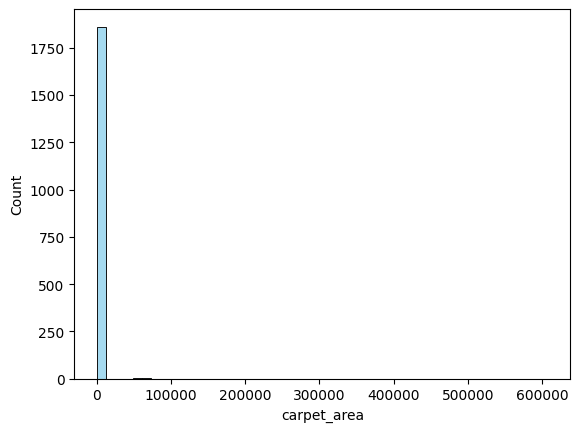

In [114]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

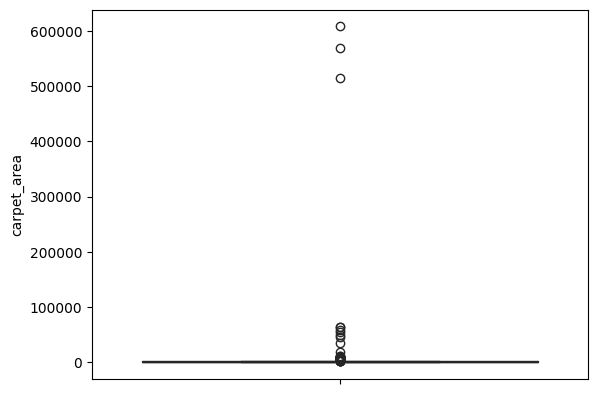

In [115]:
sns.boxplot(df['carpet_area'].dropna(), color='green')

In [116]:

df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,0,8
1,1,1,0,0,0,0,38
2,0,0,0,0,0,0,15
3,0,0,0,0,0,0,49
4,0,1,0,0,1,1,174
...,...,...,...,...,...,...,...
3798,0,0,0,0,0,0,73
3799,1,1,1,1,0,0,160
3800,0,0,0,0,0,1,67
3801,1,1,1,1,0,0,76



additional rooms

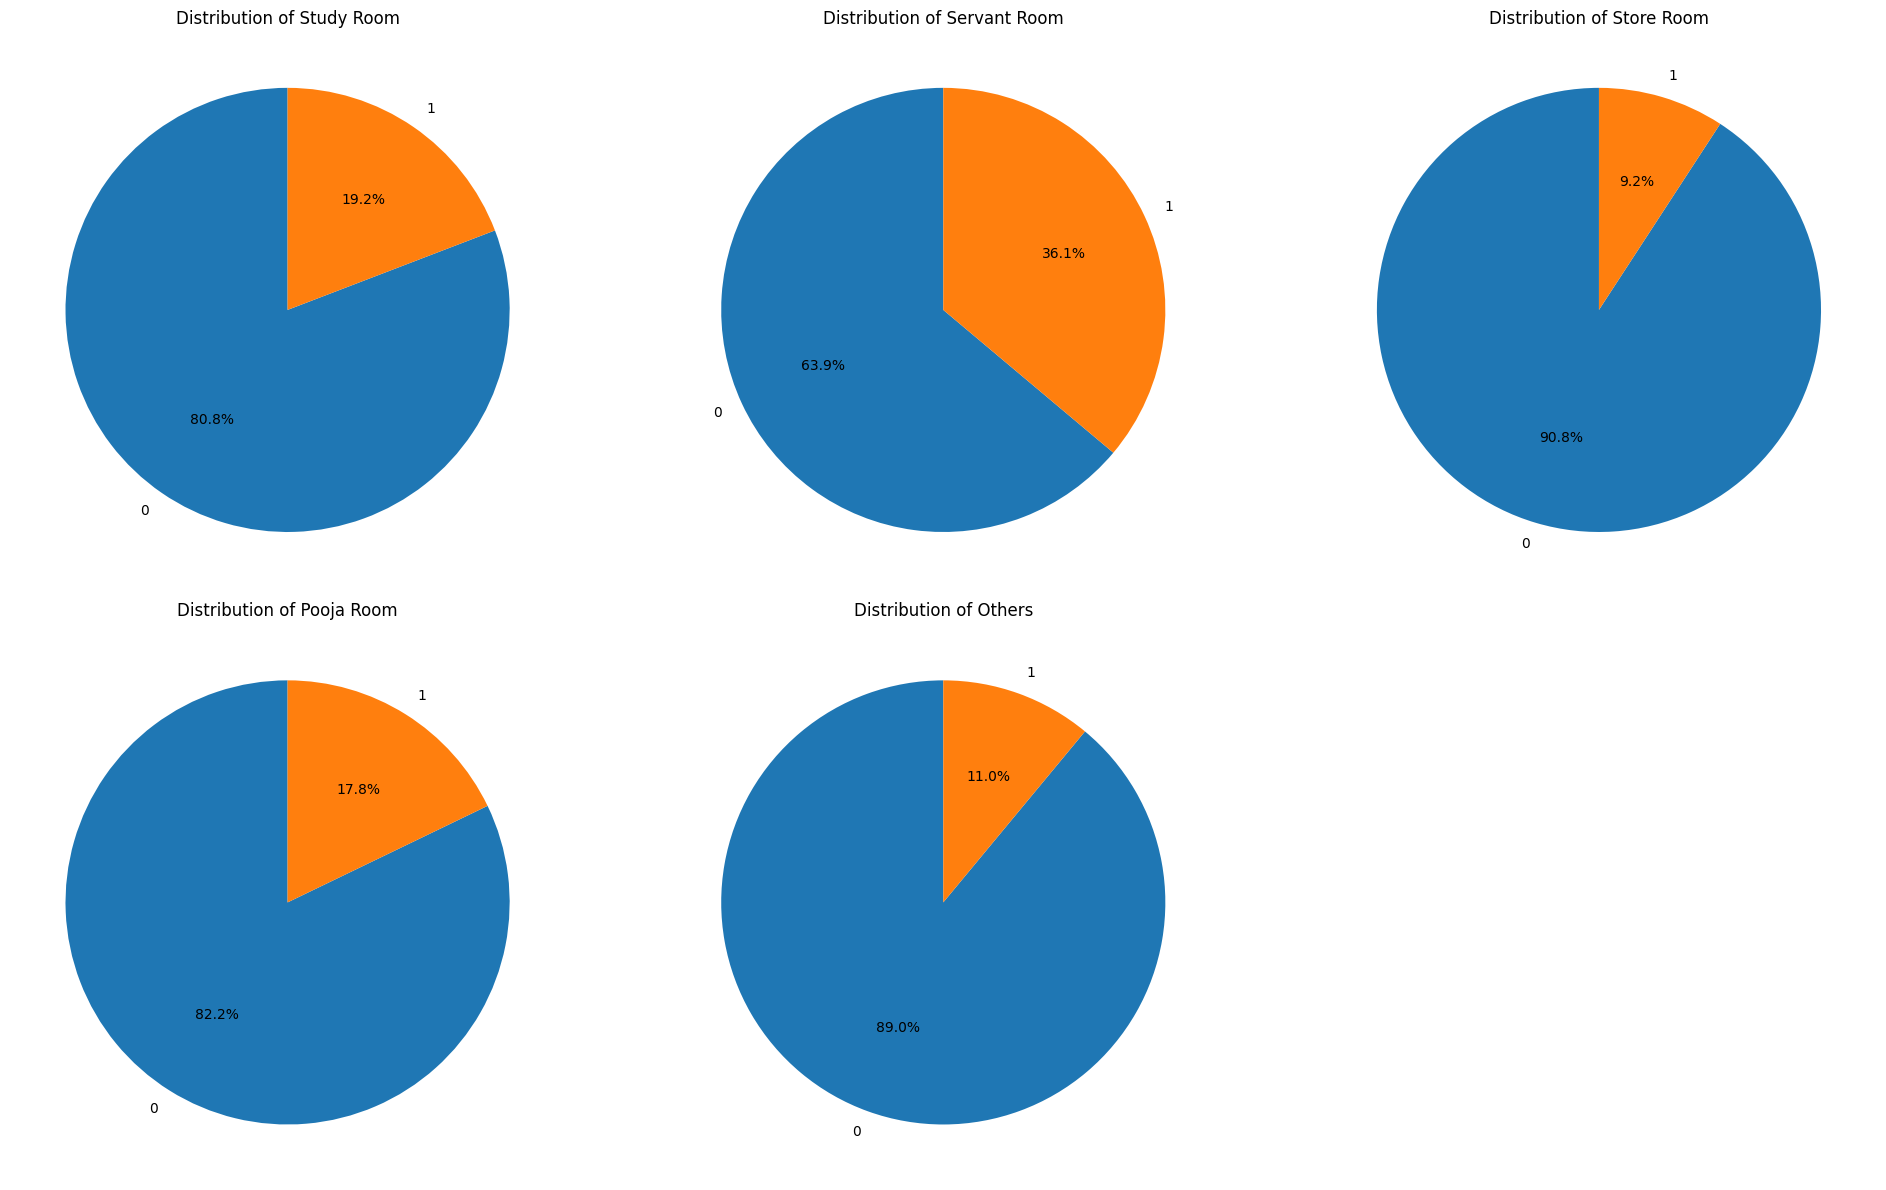

In [117]:
plt.figure(figsize=(20, 12))

#creating a subplot of pie charts for each room
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()


furnishing_type

In [118]:

df['furnishing_type'].value_counts()

furnishing_type
0    2411
1    1059
2     207
Name: count, dtype: int64

<Axes: ylabel='count'>

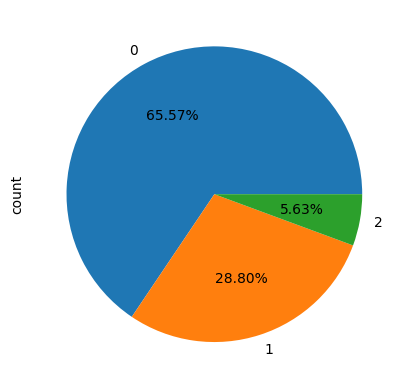

In [119]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')


luxury score

In [120]:

df['luxury_score'].isnull().sum()

np.int64(0)

In [121]:

df['luxury_score'].describe()

count    3677.000000
mean       71.512918
std        53.059082
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

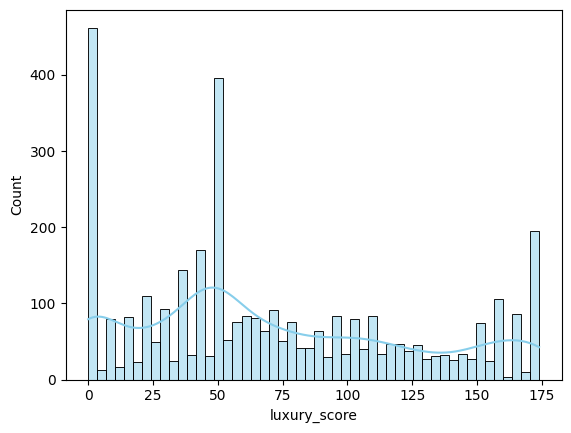

In [122]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)


In [123]:
# this is the distribution that i don't want

<Axes: ylabel='luxury_score'>

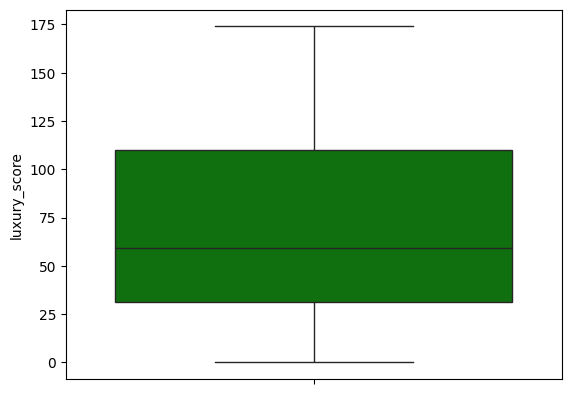

In [125]:

sns.boxplot(df['luxury_score'], color='green')

In [126]:
# major prooperty  has  IQR between  30 and 110.

In [127]:

df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174
